# Alzheimer’s Multiclass Classification – Inception

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Data Preprocessing
### Import libraries & Load grayscale data

In [2]:
import os
import cv2
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

base_dir = '/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images'
categories = ['VeryMildDemented', 'NonDemented', 'ModerateDemented', 'MildDemented']

# Load grayscale images
images = []
labels = []

for category in categories:
    path = os.path.join(base_dir, category)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128, 128))
            images.append(img)
            labels.append(categories.index(category))
        except Exception as e:
            print(f"Error: {e}")

images = np.array(images)
labels = np.array(labels)
print(f"Loaded shape: {images.shape}")

# Add channel dimension & normalize
images = np.expand_dims(images, axis=-1)
images = images.astype('float32') / 255.0
print(f"Post-norm shape: {images.shape}, range: [{images.min():.3f}, {images.max():.3f}]")

Loaded shape: (44000, 128, 128)
Post-norm shape: (44000, 128, 128, 1), range: [0.000, 1.000]


### Visualize normalized samples : 

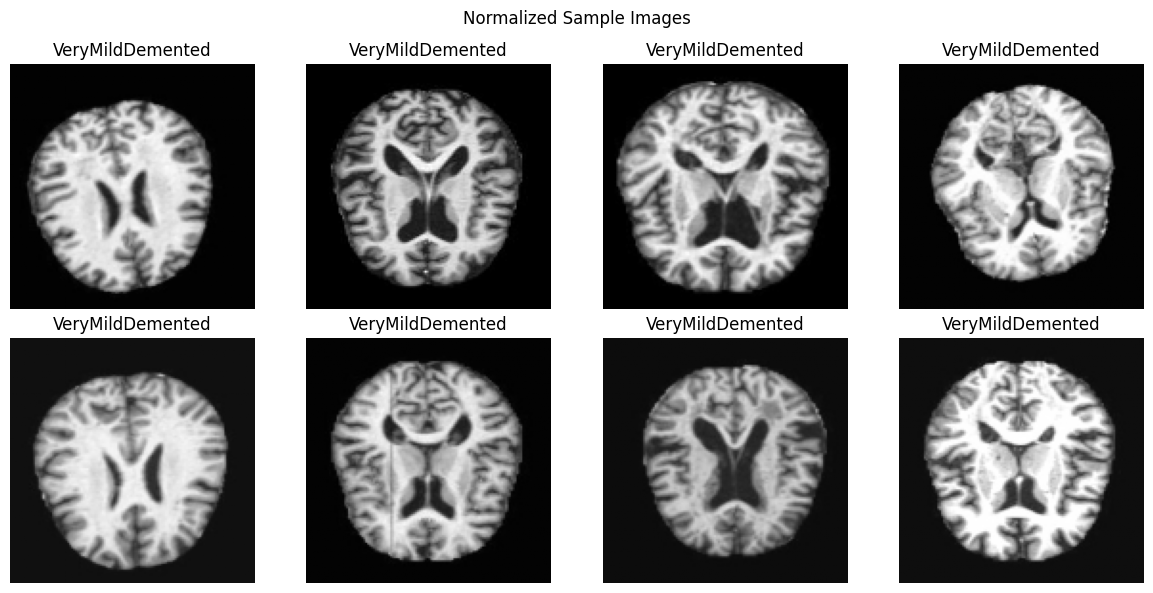

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'{categories[labels[i]]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(images[i+4].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'{categories[labels[i+4]]}')
    axes[1, i].axis('off')
plt.suptitle('Normalized Sample Images')
plt.tight_layout()
plt.show()

### Train-test split with numpy one-hot encoding

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

# One-hot encoding with numpy (avoids TF/protobuf errors)
y = np.eye(4)[labels]

X_train, X_test, y_train, y_test = train_test_split(
    images, y, test_size=0.2, stratify=labels, random_state=42
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"y_train shape: {y_train.shape}")
print(f"Class distribution - Train: {np.sum(y_train, axis=0)}")
print(f"Class distribution - Test: {np.sum(y_test, axis=0)}")

Train: 35200, Test: 8800
y_train shape: (35200, 4)
Class distribution - Train: [ 8960. 10240.  8000.  8000.]
Class distribution - Test: [2240. 2560. 2000. 2000.]


## Model Building & Training - InceptionV3
### GPU & Mixed Precision Setup : 

In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("CUDA Built:", tf.test.is_built_with_cuda())
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

# Enable mixed precision for faster training (same as VGG)
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("Logical GPUs:", tf.config.experimental.list_logical_devices('GPU'))

# GPU test
with tf.device('/GPU:0'):
    @tf.function
    def test():
        return tf.matmul(tf.random.uniform((1000, 1000)), 
                        tf.random.uniform((1000, 1000)))
    print("GPU test successful:", test().shape)

TensorFlow: 2.19.0
CUDA Built: True
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPU test successful: (1000, 1000)


### Disk Generators for InceptionV3

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input

base_dir = '/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images'

# InceptionV3 uses 299x299 input size
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(299, 299),  # InceptionV3 standard input
    color_mode='rgb',
    batch_size=64, 
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(299, 299),
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=(299, 299),
    color_mode='rgb',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print(f"Train batches: {train_generator.samples // 64}")
print("Classes:", train_generator.class_indices)

Found 35200 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.
Found 44000 images belonging to 4 classes.
Train batches: 550
Classes: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


### Build InceptionV3 Model : 

In [8]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load InceptionV3 base (frozen weights)
base_model = InceptionV3(
    weights='imagenet', 
    include_top=False, 
    input_shape=(299, 299, 3)
)
base_model.trainable = False

# Build model 
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'), 
    Dropout(0.5),  # Same dropout rate
    Dense(4, activation='softmax', dtype='float32')  # 4 classes
])

# Compile with same optimizer & learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Same LR as VGG
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,853,924 (87.18 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### Callbacks 

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        patience=10, 
        restore_best_weights=True, 
        monitor='val_accuracy'
    ),
    ModelCheckpoint(
        'best_inception_alzheimer.h5', 
        save_best_only=True, 
        monitor='val_accuracy'
    ),
    ReduceLROnPlateau(
        factor=0.5, 
        patience=5, 
        min_lr=1e-7, 
        monitor='val_loss'
    )
]

### Train InceptionV3  : 

In [10]:
history = model.fit(
    train_generator,
    epochs=50,  
    validation_data=val_generator,
    validation_freq=5,  
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1767434677.055377     135 service.cc:152] XLA service 0x792a840589d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767434677.055422     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767434679.501122     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/550 ━━━━━━━━━━━━━━━━━━━━ 3:36:51 24s/step - accuracy: 0.2344 - loss: 1.7647

I0000 00:00:1767434692.686664     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

550/550 ━━━━━━━━━━━━━━━━━━━━ 128s 232ms/step - accuracy: 0.9253 - loss: 0.2059 - learning_rate: 1.0000e-04
Epoch 47/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9248 - loss: 0.2021

550/550 ━━━━━━━━━━━━━━━━━━━━ 122s 221ms/step - accuracy: 0.9248 - loss: 0.2021 - learning_rate: 1.0000e-04
Epoch 48/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9276 - loss: 0.1970

550/550 ━━━━━━━━━━━━━━━━━━━━ 125s 226ms/step - accuracy: 0.9276 - loss: 0.1970 - learning_rate: 1.0000e-04
Epoch 49/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9293 - loss: 0.1926

550/550 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - accuracy: 0.9293 - loss: 0.1926 - learning_rate: 1.0000e-04
Epoch 50/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9278 - loss: 0.1937

550/550 ━━━━━━━━━━━━━━━━━━━━ 160s 290ms/step - accuracy: 0.9278 - loss: 0.1937 - val_accuracy: 0.8980 - val_loss: 0.2634 - learning_rate: 1.0000e-04


## Evaluation
### Plot Training Curves : 

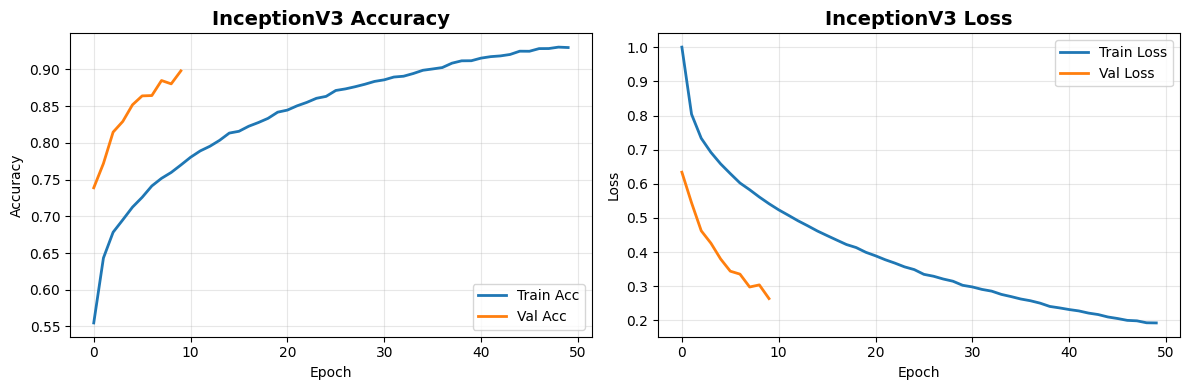

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
plt.title('InceptionV3 Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('InceptionV3 Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Test Set Evaluation : 

In [13]:
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

print("\n" + "="*60)
print("CLASSIFICATION REPORT - InceptionV3")
print("="*60)
print(classification_report(
    y_true, 
    y_pred, 
    target_names=list(train_generator.class_indices.keys()),
    digits=4
))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test Accuracy: 0.9540
Test Loss: 0.1546
688/688 ━━━━━━━━━━━━━━━━━━━━ 163s 226ms/step

CLASSIFICATION REPORT - InceptionV3
                  precision    recall  f1-score   support

    MildDemented     0.9690    0.9617    0.9653     10000
ModerateDemented     0.9982    0.9992    0.9987     10000
     NonDemented     0.9600    0.9155    0.9373     12800
VeryMildDemented     0.8980    0.9507    0.9236     11200

        accuracy                         0.9540     44000
       macro avg     0.9563    0.9568    0.9562     44000
    weighted avg     0.9549    0.9540    0.9541     44000



## Confusion Matrix : 

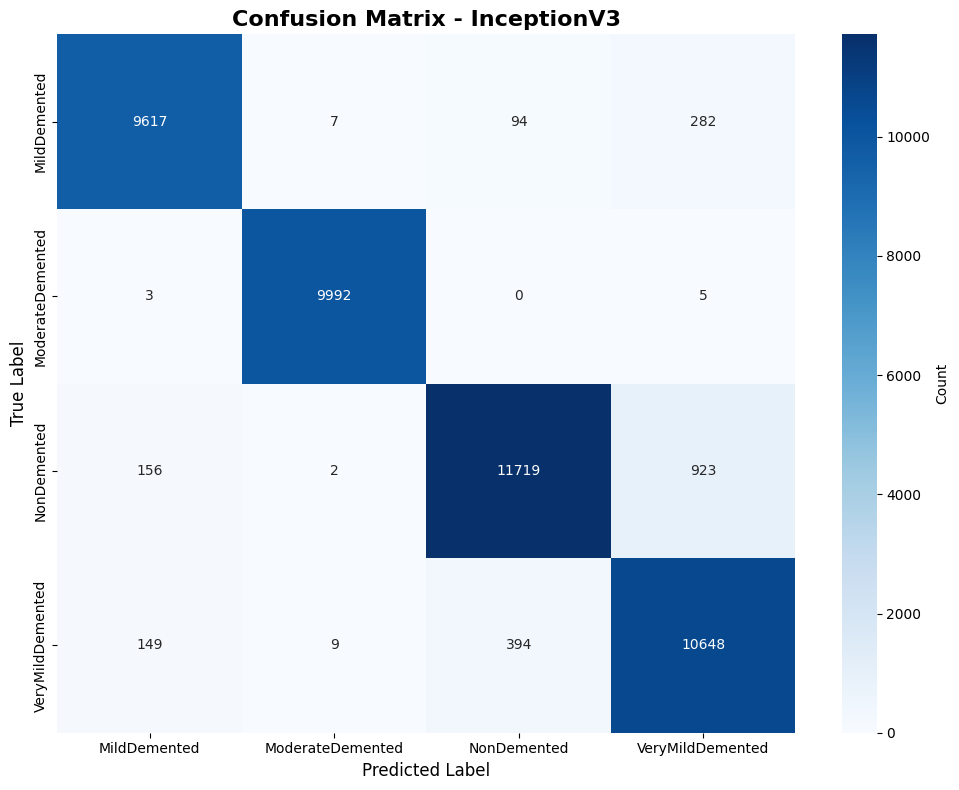


PER-CLASS ACCURACY
MildDemented        : 0.9617 (9617/10000)
ModerateDemented    : 0.9992 (9992/10000)
NonDemented         : 0.9155 (11719/12800)
VeryMildDemented    : 0.9507 (10648/11200)


In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=list(train_generator.class_indices.keys()),
    yticklabels=list(train_generator.class_indices.keys()),
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - InceptionV3', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)
for i, class_name in enumerate(train_generator.class_indices.keys()):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{class_name:20s}: {class_acc:.4f} ({cm[i, i]}/{cm[i].sum()})")

## Model Saving : 

In [15]:
# Save as native Keras (.keras) 
model.save('alzheimer_inceptionv3.keras')
print("✓ Saved: alzheimer_inceptionv3.keras")

# Save as legacy HDF5 (.h5) 
model.save('alzheimer_inceptionv3.h5')
print("✓ Saved: alzheimer_inceptionv3.h5")

# Verify saves
print("\nModel Files:")
import os
for f in ['alzheimer_inceptionv3.keras', 'alzheimer_inceptionv3.h5', 'best_inception_alzheimer.h5']:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024**2)
        print(f"  - {f}: {size:.1f} MB")


# Cell 4.2: Create ZIP for Download
import zipfile

models = [
    'alzheimer_inceptionv3.h5',
    'alzheimer_inceptionv3.keras', 
    'best_inception_alzheimer.h5'
]

zip_path = '/kaggle/working/alzheimer_inceptionv3_models.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for m in models:
        if os.path.exists(m):
            zf.write(m, m)
            
print(f"\n✓ Zipped: {zip_path}")
print("→ Download from Kaggle Output panel!")

✓ Saved: alzheimer_inceptionv3.keras
✓ Saved: alzheimer_inceptionv3.h5

Model Files:
  - alzheimer_inceptionv3.keras: 104.3 MB
  - alzheimer_inceptionv3.h5: 95.8 MB
  - best_inception_alzheimer.h5: 95.8 MB

✓ Zipped: /kaggle/working/alzheimer_inceptionv3_models.zip
→ Download from Kaggle Output panel!
